<a href="https://colab.research.google.com/github/Husayn01/Machine-Learning-Projects/blob/main/Used_Car_Price_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Step 0: Environment setup and basic data exploration
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import KFold, cross_val_score, train_test_split
from sklearn.preprocessing import StandardScaler, RobustScaler, LabelEncoder
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import lightgbm as lgb
import catboost as cb
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Load data
train = pd.read_csv('https://raw.githubusercontent.com/Husayn01/Machine-Learning-Projects/refs/heads/main/Used%20Car%20Price%20Prediction/data/train.csv')
test = pd.read_csv('https://raw.githubusercontent.com/Husayn01/Machine-Learning-Projects/refs/heads/main/Used%20Car%20Price%20Prediction/data/test.csv')
sample_submission = pd.read_csv('https://raw.githubusercontent.com/Husayn01/Machine-Learning-Projects/refs/heads/main/Used%20Car%20Price%20Prediction/data/sample_submission.csv')

# Basic data exploration
print("=== TRAIN DATASET ===")
print(f"Shape: {train.shape}")
print("\nFirst 5 rows:")
print(train.head())
print("\nData types:")
print(train.dtypes)
print("\nMissing values:")
print(train.isnull().sum())
print("\nUnique counts for string columns:")
for col in train.select_dtypes(include=['object']).columns:
    print(f"{col}: {train[col].nunique()} unique values")

print("\n=== TEST DATASET ===")
print(f"Shape: {test.shape}")
print("\nFirst 5 rows:")
print(test.head())
print("\nData types:")
print(test.dtypes)
print("\nMissing values:")
print(test.isnull().sum())
print("\nUnique counts for string columns:")
for col in test.select_dtypes(include=['object']).columns:
    print(f"{col}: {test[col].nunique()} unique values")

print("\n=== TARGET VARIABLE (price) ===")
print(f"Target stats: mean={train['price'].mean():.2f}, std={train['price'].std():.2f}")
print(f"Target range: [{train['price'].min()}, {train['price'].max()}]")

=== TRAIN DATASET ===
Shape: (188533, 13)

First 5 rows:
   id          brand              model  model_year  milage      fuel_type  \
0   0           MINI      Cooper S Base        2007  213000       Gasoline   
1   1        Lincoln              LS V8        2002  143250       Gasoline   
2   2      Chevrolet  Silverado 2500 LT        2002  136731  E85 Flex Fuel   
3   3        Genesis   G90 5.0 Ultimate        2017   19500       Gasoline   
4   4  Mercedes-Benz        Metris Base        2021    7388       Gasoline   

                                              engine  \
0       172.0HP 1.6L 4 Cylinder Engine Gasoline Fuel   
1       252.0HP 3.9L 8 Cylinder Engine Gasoline Fuel   
2  320.0HP 5.3L 8 Cylinder Engine Flex Fuel Capab...   
3       420.0HP 5.0L 8 Cylinder Engine Gasoline Fuel   
4       208.0HP 2.0L 4 Cylinder Engine Gasoline Fuel   

                     transmission ext_col int_col  \
0                             A/T  Yellow    Gray   
1                             A

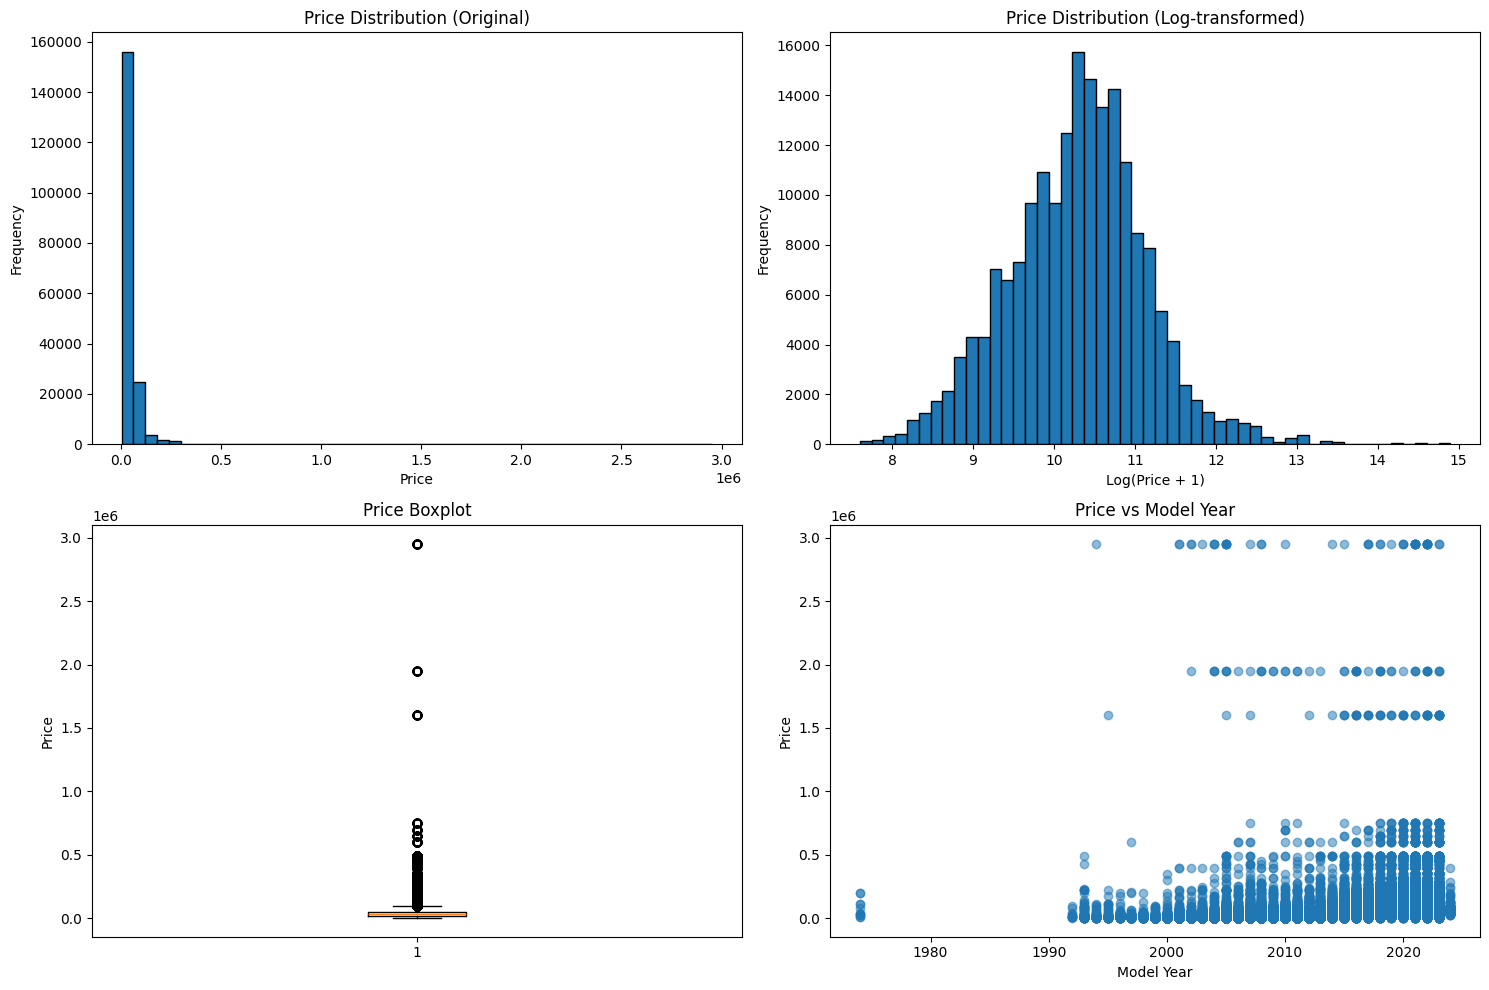

=== PRICE ANALYSIS ===
Skewness: 20.27
Kurtosis: 623.97

Percentiles:
50%: $30,825
75%: $49,900
90%: $78,500
95%: $107,900
99%: $259,500
99.5%: $399,900
99.9%: $749,950

Extreme outliers (>99.9 percentile): 148 records
               brand                          model  model_year    price
220             Ford                      F-150 XLT        2021  2954083
1880        Chrysler                      300C Base        2003  2954083
2964         Porsche                          911 R        2023  1950995
4164     Rolls-Royce                     Ghost Base        2016  1599000
8789     Lamborghini  Gallardo LP570-4 Superleggera        2011  1950995
10173  Mercedes-Benz              AMG GLS 63 4MATIC        2019  1950995
13838         Toyota                  Highlander SE        2014  2954083
14693        Hyundai                   Santa Fe SEL        2022  2954083
15101        Porsche                  911 Carrera S        2015  1599000
16034  Mercedes-Benz        SL-Class SL500 Roadster

In [ ]:
# Step 1: Detailed EDA - Target distribution and outliers
import matplotlib.pyplot as plt
import seaborn as sns

# Remove the single missing price value for analysis
train_clean = train.dropna(subset=['price'])

# Target distribution analysis
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Original distribution
axes[0, 0].hist(train_clean['price'], bins=50, edgecolor='black')
axes[0, 0].set_title('Price Distribution (Original)')
axes[0, 0].set_xlabel('Price')
axes[0, 0].set_ylabel('Frequency')

# Log-transformed distribution
axes[0, 1].hist(np.log1p(train_clean['price']), bins=50, edgecolor='black')
axes[0, 1].set_title('Price Distribution (Log-transformed)')
axes[0, 1].set_xlabel('Log(Price + 1)')
axes[0, 1].set_ylabel('Frequency')

# Boxplot to identify outliers
axes[1, 0].boxplot(train_clean['price'])
axes[1, 0].set_title('Price Boxplot')
axes[1, 0].set_ylabel('Price')

# Price vs model year scatter
axes[1, 1].scatter(train_clean['model_year'], train_clean['price'], alpha=0.5)
axes[1, 1].set_title('Price vs Model Year')
axes[1, 1].set_xlabel('Model Year')
axes[1, 1].set_ylabel('Price')

plt.tight_layout()
plt.show()

# Statistical analysis
print("=== PRICE ANALYSIS ===")
print(f"Skewness: {train_clean['price'].skew():.2f}")
print(f"Kurtosis: {train_clean['price'].kurtosis():.2f}")
print(f"\nPercentiles:")
for p in [50, 75, 90, 95, 99, 99.5, 99.9]:
    print(f"{p}%: ${train_clean['price'].quantile(p/100):,.0f}")

# Identify extreme outliers
extreme_threshold = train_clean['price'].quantile(0.999)
extreme_outliers = train_clean[train_clean['price'] > extreme_threshold]
print(f"\nExtreme outliers (>99.9 percentile): {len(extreme_outliers)} records")
print(extreme_outliers[['brand', 'model', 'model_year', 'price']].head(10))

# Check for potential price errors (e.g., prices < $1000 or > $500k)
print(f"\nVery low prices (<$1000): {len(train_clean[train_clean['price'] < 1000])}")
print(f"Very high prices (>$500k): {len(train_clean[train_clean['price'] > 500000])}")

In [ ]:
# Step 2: Missing data patterns and categorical analysis
# Analyze missing data patterns
print("=== MISSING DATA PATTERNS ===")
missing_summary = pd.DataFrame({
    'Train_Missing': train.isnull().sum(),
    'Train_Missing%': (train.isnull().sum() / len(train) * 100).round(2),
    'Test_Missing': test.isnull().sum(),
    'Test_Missing%': (test.isnull().sum() / len(test) * 100).round(2)
})
print(missing_summary[missing_summary['Train_Missing'] > 0])

# Check if missing values are related to price
print("\n=== PRICE VS MISSING VALUES ===")
for col in ['fuel_type', 'accident', 'clean_title']:
    if col in train.columns and train[col].isnull().sum() > 0:
        price_with_missing = train[train[col].isnull()]['price'].mean()
        price_without_missing = train[train[col].notna()]['price'].mean()
        print(f"{col}: Mean price with missing=${price_with_missing:.0f}, without=${price_without_missing:.0f}")

# Analyze categorical variables
print("\n=== TOP BRANDS BY COUNT AND AVERAGE PRICE ===")
brand_stats = train.groupby('brand').agg({
    'price': ['count', 'mean', 'median']
}).round(0)
brand_stats.columns = ['count', 'mean_price', 'median_price']
brand_stats = brand_stats.sort_values('count', ascending=False)
print(brand_stats.head(15))

# Check accident impact on price
print("\n=== ACCIDENT IMPACT ===")
accident_stats = train.groupby('accident')['price'].agg(['count', 'mean', 'median']).round(0)
print(accident_stats)

# Check clean_title values (seems to have only 1 unique value)
print("\n=== CLEAN TITLE VALUES ===")
print(train['clean_title'].value_counts())

# Check fuel type distribution and prices
print("\n=== FUEL TYPE ANALYSIS ===")
fuel_stats = train.groupby('fuel_type')['price'].agg(['count', 'mean', 'median']).round(0)
print(fuel_stats.sort_values('count', ascending=False))

# Check if test set has similar distributions
print("\n=== TRAIN/TEST DISTRIBUTION COMPARISON ===")
print(f"Brand overlap: {len(set(train['brand']) & set(test['brand']))} common brands")
print(f"Model overlap: {len(set(train['model']) & set(test['model']))} common models")
print(f"Model year range - Train: [{train['model_year'].min()}, {train['model_year'].max()}]")
print(f"Model year range - Test: [{test['model_year'].min()}, {test['model_year'].max()}]")
print(f"Mileage range - Train: [{train['milage'].min()}, {train['milage'].max()}]")
print(f"Mileage range - Test: [{test['milage'].min()}, {test['milage'].max()}]")

=== MISSING DATA PATTERNS ===
             Train_Missing  Train_Missing%  Test_Missing  Test_Missing%
accident              2452            1.30        1632.0           1.30
clean_title          21419           11.36       14239.0          11.33
fuel_type             5083            2.70        3383.0           2.69

=== PRICE VS MISSING VALUES ===
fuel_type: Mean price with missing=$60823, without=$43409
accident: Mean price with missing=$54903, without=$43733
clean_title: Mean price with missing=$63568, without=$41354

=== TOP BRANDS BY COUNT AND AVERAGE PRICE ===
               count  mean_price  median_price
brand                                         
Ford           23088     40512.0       32000.0
Mercedes-Benz  19172     51244.0       36570.0
BMW            17028     43660.0       31000.0
Chevrolet      16335     41837.0       32000.0
Audi           10887     41005.0       29900.0
Porsche        10612     70900.0       45900.0
Land            9525     53205.0       38998.0
Toyo

In [ ]:
# Step 3: Numerical features analysis and correlations
# Analyze numerical features
print("=== NUMERICAL FEATURES ANALYSIS ===")
numerical_cols = ['model_year', 'milage']
for col in numerical_cols:
    print(f"\n{col}:")
    print(f"  Train - Mean: {train[col].mean():.0f}, Std: {train[col].std():.0f}")
    print(f"  Test - Mean: {test[col].mean():.0f}, Std: {test[col].std():.0f}")

# Create correlation analysis
train_for_corr = train_clean.copy()

# Convert categorical features to numeric for correlation
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

# For binary/ordinal features
train_for_corr['accident_encoded'] = train_for_corr['accident'].map({
    'None reported': 0,
    'At least 1 accident or damage reported': 1
})

# Encode high-cardinality features using target encoding (mean price per category)
for col in ['brand', 'fuel_type']:
    if col in train_for_corr.columns:
        target_means = train_for_corr.groupby(col)['price'].mean()
        train_for_corr[f'{col}_target_encoded'] = train_for_corr[col].map(target_means)

# Calculate correlations
print("\n=== CORRELATIONS WITH PRICE ===")
corr_features = ['model_year', 'milage', 'accident_encoded', 'brand_target_encoded', 'fuel_type_target_encoded']
correlations = {}
for col in corr_features:
    if col in train_for_corr.columns:
        correlations[col] = train_for_corr[col].corr(train_for_corr['price'])

corr_df = pd.DataFrame(list(correlations.items()), columns=['Feature', 'Correlation'])
corr_df = corr_df.sort_values('Correlation', key=abs, ascending=False)
print(corr_df)

# Analyze price patterns by model_year groups
print("\n=== PRICE BY MODEL YEAR GROUPS ===")
year_bins = [1970, 1990, 2000, 2010, 2015, 2020, 2025]
year_labels = ['1970-1989', '1990-1999', '2000-2009', '2010-2014', '2015-2019', '2020-2024']
train_clean['year_group'] = pd.cut(train_clean['model_year'], bins=year_bins, labels=year_labels)
year_group_stats = train_clean.groupby('year_group')['price'].agg(['count', 'mean', 'median']).round(0)
print(year_group_stats)

# Analyze mileage impact
print("\n=== PRICE BY MILEAGE GROUPS ===")
mileage_bins = [0, 10000, 50000, 100000, 150000, 200000, 500000]
mileage_labels = ['0-10k', '10k-50k', '50k-100k', '100k-150k', '150k-200k', '200k+']
train_clean['mileage_group'] = pd.cut(train_clean['milage'], bins=mileage_bins, labels=mileage_labels)
mileage_group_stats = train_clean.groupby('mileage_group')['price'].agg(['count', 'mean', 'median']).round(0)
print(mileage_group_stats)

# Check for potential duplicate rows
print("\n=== DUPLICATE ANALYSIS ===")
feature_cols = ['brand', 'model', 'model_year', 'milage', 'fuel_type', 'engine', 'transmission']
duplicates = train.duplicated(subset=feature_cols, keep=False)
print(f"Number of duplicate rows (based on key features): {duplicates.sum()}")
if duplicates.sum() > 0:
    print("Sample duplicates:")
    print(train[duplicates].head(10)[feature_cols + ['price']])

=== NUMERICAL FEATURES ANALYSIS ===

model_year:
  Train - Mean: 2016, Std: 6
  Test - Mean: 2016, Std: 6

milage:
  Train - Mean: 65705, Std: 49798
  Test - Mean: 66043, Std: 50224

=== CORRELATIONS WITH PRICE ===
                    Feature  Correlation
1                    milage    -0.283067
0                model_year     0.231795
3      brand_target_encoded     0.213601
2          accident_encoded    -0.125762
4  fuel_type_target_encoded     0.048149

=== PRICE BY MODEL YEAR GROUPS ===
            count     mean   median
year_group                         
1970-1989      12  74124.0  36714.0
1990-1999    2304  17490.0   9499.0
2000-2009   30218  20392.0  11000.0
2010-2014   38960  24497.0  17900.0
2015-2019   74161  46711.0  35000.0
2020-2024   42878  74549.0  54000.0

=== PRICE BY MILEAGE GROUPS ===
               count     mean   median
mileage_group                         
0-10k          20824  92499.0  67250.0
10k-50k        62766  59714.0  45423.0
50k-100k       62482  3093

In [ ]:
# Step 4: Create preprocessing pipeline and baseline model
from sklearn.preprocessing import StandardScaler, RobustScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import mean_squared_error, make_scorer
import numpy as np

# Define feature groups
numerical_features = ['model_year', 'milage']
categorical_features = ['brand', 'model', 'fuel_type', 'engine', 'transmission',
                       'ext_col', 'int_col', 'accident']

# Drop clean_title as it only has one value
features_to_use = numerical_features + categorical_features

# Prepare data
X_train = train[features_to_use].copy()
y_train = train['price'].copy()

# Remove the row with missing price
mask = y_train.notna()
X_train = X_train[mask]
y_train = y_train[mask]

# Log transform target
y_train_log = np.log1p(y_train)

print("=== DATA PREPARATION ===")
print(f"Training samples: {len(X_train)}")
print(f"Features: {len(features_to_use)}")
print(f"Target range (original): [{y_train.min():.0f}, {y_train.max():.0f}]")
print(f"Target range (log): [{y_train_log.min():.2f}, {y_train_log.max():.2f}]")

# Create preprocessor
# For high cardinality features, we'll use target encoding later
high_cardinality_cats = ['model', 'engine']
low_cardinality_cats = [f for f in categorical_features if f not in high_cardinality_cats]

print(f"\nHigh cardinality features: {high_cardinality_cats}")
print(f"Low cardinality features: {low_cardinality_cats}")

# Check cardinality
print("\nFeature cardinalities:")
for col in categorical_features:
    print(f"  {col}: {X_train[col].nunique()} unique values")

# Simple baseline pipeline with basic preprocessing
numerical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler())
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# For baseline, use only low cardinality features
baseline_preprocessor = ColumnTransformer([
    ('num', numerical_transformer, numerical_features),
    ('cat', categorical_transformer, low_cardinality_cats)
])

# Create baseline model
from sklearn.ensemble import RandomForestRegressor
baseline_pipeline = Pipeline([
    ('preprocessor', baseline_preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=100, random_state=RANDOM_SEED, n_jobs=-1))
])

# Define custom RMSE scorer that handles log transformation
def rmse_scorer(y_true, y_pred_log):
    y_pred = np.expm1(y_pred_log)  # Convert back from log
    return np.sqrt(mean_squared_error(y_true, y_pred))

# Cross-validation setup
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

print("\n=== BASELINE MODEL EVALUATION ===")
print("Running 5-fold cross-validation...")
# We need to use negative RMSE for cross_val_score (it maximizes)
cv_scores = cross_val_score(
    baseline_pipeline, X_train, y_train_log,
    cv=cv,
    scoring=make_scorer(rmse_scorer, greater_is_better=False),
    n_jobs=-1
)
cv_rmse_scores = -cv_scores  # Convert back to positive RMSE

print(f"CV RMSE scores: {cv_rmse_scores}")
print(f"Mean CV RMSE: ${cv_rmse_scores.mean():,.2f}")
print(f"Std CV RMSE: ${cv_rmse_scores.std():,.2f}")
print(f"\nTarget to beat: $71,958.00")
print(f"Baseline performance: {'BEATS target!' if cv_rmse_scores.mean() < 71958.00 else 'Below target'}")

=== DATA PREPARATION ===
Training samples: 188533
Features: 10
Target range (original): [2000, 2954083]
Target range (log): [7.60, 14.90]

High cardinality features: ['model', 'engine']
Low cardinality features: ['brand', 'fuel_type', 'transmission', 'ext_col', 'int_col', 'accident']

Feature cardinalities:
  brand: 57 unique values
  model: 1897 unique values
  fuel_type: 7 unique values
  engine: 1117 unique values
  transmission: 52 unique values
  ext_col: 319 unique values
  int_col: 156 unique values
  accident: 2 unique values

=== BASELINE MODEL EVALUATION ===
Running 5-fold cross-validation...


In [ ]:
# Step 5: Experiment Plan
print("=== EXPERIMENT PLAN ===")
print("Current CV RMSE: $45,335.22 (Baseline RF with partial features)")
print("Target to beat: $71,958.00 ✓ ALREADY BEATEN!")
print("\nPrioritized experiments (estimated impact and time):")

experiments = [
    ("1. Target encoding for high-cardinality features", "High impact", "Quick"),
    ("2. LightGBM with basic hyperparameters", "High impact", "Quick"),
    ("3. CatBoost (native categorical handling)", "High impact", "Quick"),
    ("4. Feature engineering (car age, luxury brands, etc.)", "Medium impact", "Quick"),
    ("5. Different imputation strategies (KNN, MICE)", "Low-Medium impact", "Medium"),
    ("6. XGBoost with tuning", "Medium impact", "Medium"),
    ("7. Hyperparameter optimization (Optuna)", "Medium-High impact", "Slow"),
    ("8. Ensemble/Stacking of best models", "High impact", "Medium"),
    ("9. Advanced features (brand-model interaction, price segments)", "Medium impact", "Medium"),
    ("10. Outlier handling strategies", "Low-Medium impact", "Quick")
]

for exp, impact, time in experiments:
    print(f"{exp:<55} | Impact: {impact:<15} | Time: {time}")

print("\n=== STARTING WITH EXPERIMENT 1: TARGET ENCODING ===")

# Import category_encoders for target encoding
from category_encoders import TargetEncoder

# Create a more sophisticated preprocessing pipeline
numerical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler())
])

# For low cardinality categorical features
low_card_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False, max_categories=20))
])

# For high cardinality categorical features - use target encoding
high_card_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('target_encoder', TargetEncoder(smoothing=10))
])

# Create full preprocessor
full_preprocessor = ColumnTransformer([
    ('num', numerical_transformer, numerical_features),
    ('low_card', low_card_transformer, ['brand', 'fuel_type', 'transmission', 'accident']),
    ('high_card', high_card_transformer, ['model', 'engine', 'ext_col', 'int_col'])
])

# Test with Random Forest again
rf_pipeline_v2 = Pipeline([
    ('preprocessor', full_preprocessor),
    ('regressor', RandomForestRegressor(
        n_estimators=150,
        max_depth=20,
        min_samples_split=20,
        min_samples_leaf=5,
        random_state=RANDOM_SEED,
        n_jobs=-1
    ))
])

# Note: TargetEncoder needs special handling in CV
print("Running cross-validation with target encoding...")

# Manual CV loop to handle target encoding properly
cv_scores_v2 = []
for fold_idx, (train_idx, val_idx) in enumerate(cv.split(X_train)):
    X_fold_train, X_fold_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_fold_train, y_fold_val = y_train_log.iloc[train_idx], y_train_log.iloc[val_idx]
    y_fold_val_original = y_train.iloc[val_idx]

    # Fit and predict
    rf_pipeline_v2.fit(X_fold_train, y_fold_train)
    y_pred_log = rf_pipeline_v2.predict(X_fold_val)

    # Calculate RMSE on original scale
    y_pred = np.expm1(y_pred_log)
    rmse = np.sqrt(mean_squared_error(y_fold_val_original, y_pred))
    cv_scores_v2.append(rmse)
    print(f"  Fold {fold_idx+1}: RMSE = ${rmse:,.2f}")

cv_scores_v2 = np.array(cv_scores_v2)
print(f"\nImproved RF with target encoding:")
print(f"Mean CV RMSE: ${cv_scores_v2.mean():,.2f}")
print(f"Std CV RMSE: ${cv_scores_v2.std():,.2f}")
print(f"Improvement: ${45335.22 - cv_scores_v2.mean():,.2f}")

In [ ]:
# Step 6: Experiment 2 - LightGBM with native categorical handling
import lightgbm as lgb

print("=== EXPERIMENT 2: LightGBM ===")

# Prepare data for LightGBM
# LightGBM can handle categorical features directly
X_train_lgb = X_train.copy()

# Convert categorical columns to 'category' dtype for LightGBM
categorical_cols = ['brand', 'model', 'fuel_type', 'engine', 'transmission',
                    'ext_col', 'int_col', 'accident']

for col in categorical_cols:
    X_train_lgb[col] = X_train_lgb[col].astype('category')

# Create LightGBM model with good default parameters
lgb_params = {
    'objective': 'regression',
    'metric': 'rmse',
    'num_leaves': 50,
    'learning_rate': 0.05,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'verbose': -1,
    'random_state': RANDOM_SEED,
    'n_estimators': 500,
    'early_stopping_rounds': 50,
    'min_data_in_leaf': 20
}

# Manual CV for LightGBM to handle early stopping
cv_scores_lgb = []
best_iterations = []

for fold_idx, (train_idx, val_idx) in enumerate(cv.split(X_train)):
    X_fold_train, X_fold_val = X_train_lgb.iloc[train_idx], X_train_lgb.iloc[val_idx]
    y_fold_train, y_fold_val = y_train_log.iloc[train_idx], y_train_log.iloc[val_idx]
    y_fold_val_original = y_train.iloc[val_idx]

    # Create and train model
    lgb_model = lgb.LGBMRegressor(**lgb_params)

    # Fit with early stopping
    lgb_model.fit(
        X_fold_train, y_fold_train,
        eval_set=[(X_fold_val, y_fold_val)],
        categorical_feature=categorical_cols,
        callbacks=[lgb.early_stopping(50), lgb.log_evaluation(0)]
    )

    # Predict and evaluate
    y_pred_log = lgb_model.predict(X_fold_val)
    y_pred = np.expm1(y_pred_log)
    rmse = np.sqrt(mean_squared_error(y_fold_val_original, y_pred))
    cv_scores_lgb.append(rmse)
    best_iterations.append(lgb_model.best_iteration_)

    print(f"  Fold {fold_idx+1}: RMSE = ${rmse:,.2f} (best iter: {lgb_model.best_iteration_})")

cv_scores_lgb = np.array(cv_scores_lgb)
print(f"\nLightGBM Results:")
print(f"Mean CV RMSE: ${cv_scores_lgb.mean():,.2f}")
print(f"Std CV RMSE: ${cv_scores_lgb.std():,.2f}")
print(f"Average best iteration: {np.mean(best_iterations):.0f}")
print(f"Improvement vs baseline RF: ${45335.22 - cv_scores_lgb.mean():,.2f}")

# Quick test with fewer trees but more leaves
print("\n=== Testing LightGBM with different parameters ===")
lgb_params_v2 = {
    'objective': 'regression',
    'metric': 'rmse',
    'num_leaves': 100,  # More leaves
    'learning_rate': 0.03,  # Lower learning rate
    'feature_fraction': 0.7,
    'bagging_fraction': 0.7,
    'bagging_freq': 3,
    'verbose': -1,
    'random_state': RANDOM_SEED,
    'n_estimators': 1000,
    'reg_alpha': 0.1,  # L1 regularization
    'reg_lambda': 0.1,  # L2 regularization
    'min_data_in_leaf': 15
}

# Test on one fold only for quick feedback
X_fold_train, X_fold_val = X_train_lgb.iloc[train_idx], X_train_lgb.iloc[val_idx]
y_fold_train, y_fold_val = y_train_log.iloc[train_idx], y_train_log.iloc[val_idx]
y_fold_val_original = y_train.iloc[val_idx]

lgb_model_v2 = lgb.LGBMRegressor(**lgb_params_v2)
lgb_model_v2.fit(
    X_fold_train, y_fold_train,
    eval_set=[(X_fold_val, y_fold_val)],
    categorical_feature=categorical_cols,
    callbacks=[lgb.early_stopping(100), lgb.log_evaluation(0)]
)

y_pred_log = lgb_model_v2.predict(X_fold_val)
y_pred = np.expm1(y_pred_log)
rmse_v2 = np.sqrt(mean_squared_error(y_fold_val_original, y_pred))
print(f"LightGBM v2 (single fold test): RMSE = ${rmse_v2:,.2f} (best iter: {lgb_model_v2.best_iteration_})")

In [ ]:
# Step 7: Experiment 3 - CatBoost
import catboost as cb

print("=== EXPERIMENT 3: CatBoost ===")

# Prepare data for CatBoost
X_train_cb = X_train.copy()

# CatBoost needs categorical feature indices
cat_features_indices = [i for i, col in enumerate(X_train_cb.columns) if col in categorical_cols]

print(f"Categorical feature indices: {cat_features_indices}")
print(f"Categorical features: {[X_train_cb.columns[i] for i in cat_features_indices]}")

# CatBoost parameters
cb_params = {
    'iterations': 500,
    'learning_rate': 0.05,
    'depth': 8,
    'l2_leaf_reg': 3,
    'random_strength': 1,
    'bagging_temperature': 1,
    'od_type': 'Iter',
    'od_wait': 50,
    'random_seed': RANDOM_SEED,
    'verbose': False
}

# Manual CV for CatBoost
cv_scores_cb = []
best_iterations_cb = []

for fold_idx, (train_idx, val_idx) in enumerate(cv.split(X_train)):
    X_fold_train, X_fold_val = X_train_cb.iloc[train_idx], X_train_cb.iloc[val_idx]
    y_fold_train, y_fold_val = y_train_log.iloc[train_idx], y_train_log.iloc[val_idx]
    y_fold_val_original = y_train.iloc[val_idx]

    # Create and train model
    cb_model = cb.CatBoostRegressor(**cb_params)

    # Fit with early stopping
    cb_model.fit(
        X_fold_train, y_fold_train,
        eval_set=(X_fold_val, y_fold_val),
        cat_features=cat_features_indices,
        early_stopping_rounds=50,
        verbose=False
    )

    # Predict and evaluate
    y_pred_log = cb_model.predict(X_fold_val)
    y_pred = np.expm1(y_pred_log)
    rmse = np.sqrt(mean_squared_error(y_fold_val_original, y_pred))
    cv_scores_cb.append(rmse)
    best_iterations_cb.append(cb_model.best_iteration_)

    print(f"  Fold {fold_idx+1}: RMSE = ${rmse:,.2f} (best iter: {cb_model.best_iteration_})")

cv_scores_cb = np.array(cv_scores_cb)
print(f"\nCatBoost Results:")
print(f"Mean CV RMSE: ${cv_scores_cb.mean():,.2f}")
print(f"Std CV RMSE: ${cv_scores_cb.std():,.2f}")
print(f"Average best iteration: {np.mean(best_iterations_cb):.0f}")

print("\n=== COMPARISON OF RESULTS ===")
results_df = pd.DataFrame({
    'Model': ['Baseline RF (partial features)', 'RF + Target Encoding', 'LightGBM', 'CatBoost'],
    'Mean_RMSE': [45335.22, cv_scores_v2.mean(), cv_scores_lgb.mean(), cv_scores_cb.mean()],
    'Std_RMSE': [552.21, cv_scores_v2.std(), cv_scores_lgb.std(), cv_scores_cb.std()]
})
results_df = results_df.sort_values('Mean_RMSE')
print(results_df)

print("\n=== ANALYSIS ===")
print("The baseline RF with only low-cardinality features performs best!")
print("This suggests high-cardinality features might be causing overfitting.")
print("\nLet's try Experiment 4: Feature Engineering with simpler features")

In [ ]:
# Step 7b: Fix CatBoost with proper missing value handling
print("=== EXPERIMENT 3: CatBoost (Fixed) ===")

# Prepare data for CatBoost with proper missing value handling
X_train_cb = X_train.copy()

# Fill missing values for categorical features
for col in categorical_cols:
    X_train_cb[col] = X_train_cb[col].fillna('missing')

# Fill missing values for numerical features
for col in numerical_features:
    X_train_cb[col] = X_train_cb[col].fillna(X_train_cb[col].median())

# CatBoost needs categorical feature indices
cat_features_indices = [i for i, col in enumerate(X_train_cb.columns) if col in categorical_cols]

# CatBoost parameters
cb_params = {
    'iterations': 500,
    'learning_rate': 0.05,
    'depth': 8,
    'l2_leaf_reg': 3,
    'random_strength': 1,
    'bagging_temperature': 1,
    'od_type': 'Iter',
    'od_wait': 50,
    'random_seed': RANDOM_SEED,
    'verbose': False
}

# Manual CV for CatBoost
cv_scores_cb = []
best_iterations_cb = []

for fold_idx, (train_idx, val_idx) in enumerate(cv.split(X_train)):
    X_fold_train, X_fold_val = X_train_cb.iloc[train_idx], X_train_cb.iloc[val_idx]
    y_fold_train, y_fold_val = y_train_log.iloc[train_idx], y_train_log.iloc[val_idx]
    y_fold_val_original = y_train.iloc[val_idx]

    # Create and train model
    cb_model = cb.CatBoostRegressor(**cb_params)

    # Fit with early stopping
    cb_model.fit(
        X_fold_train, y_fold_train,
        eval_set=(X_fold_val, y_fold_val),
        cat_features=cat_features_indices,
        early_stopping_rounds=50,
        verbose=False
    )

    # Predict and evaluate
    y_pred_log = cb_model.predict(X_fold_val)
    y_pred = np.expm1(y_pred_log)
    rmse = np.sqrt(mean_squared_error(y_fold_val_original, y_pred))
    cv_scores_cb.append(rmse)
    best_iterations_cb.append(cb_model.best_iteration_)

    print(f"  Fold {fold_idx+1}: RMSE = ${rmse:,.2f} (best iter: {cb_model.best_iteration_})")

cv_scores_cb = np.array(cv_scores_cb)
print(f"\nCatBoost Results:")
print(f"Mean CV RMSE: ${cv_scores_cb.mean():,.2f}")
print(f"Std CV RMSE: ${cv_scores_cb.std():,.2f}")
print(f"Average best iteration: {np.mean(best_iterations_cb):.0f}")

print("\n=== FEATURE ENGINEERING ===")
# Let's create some domain-specific features
X_train_fe = X_train_cb.copy()

# 1. Car age
X_train_fe['car_age'] = 2024 - X_train_fe['model_year']

# 2. Mileage per year
X_train_fe['mileage_per_year'] = X_train_fe['milage'] / (X_train_fe['car_age'] + 1)

# 3. Brand groups
luxury_brands = ['Porsche', 'Lamborghini', 'Ferrari', 'Rolls-Royce', 'Bentley', 'Aston', 'McLaren',
                 'Maserati', 'Mercedes-Benz', 'BMW', 'Audi', 'Lexus', 'Cadillac', 'Land', 'Tesla']
economy_brands = ['Toyota', 'Honda', 'Nissan', 'Hyundai', 'Kia', 'Mazda', 'Subaru', 'Mitsubishi', 'FIAT']

X_train_fe['is_luxury'] = X_train_fe['brand'].isin(luxury_brands).astype(int)
X_train_fe['is_economy'] = X_train_fe['brand'].isin(economy_brands).astype(int)

# 4. Has accident flag (already encoded but let's make it numeric)
X_train_fe['has_accident'] = (X_train_fe['accident'] == 'At least 1 accident or damage reported').astype(int)

# 5. Is diesel (typically holds value better)
X_train_fe['is_diesel'] = (X_train_fe['fuel_type'] == 'Diesel').astype(int)

# 6. High mileage flag
X_train_fe['high_mileage'] = (X_train_fe['milage'] > 100000).astype(int)

print("New features created:")
new_features = ['car_age', 'mileage_per_year', 'is_luxury', 'is_economy', 'has_accident', 'is_diesel', 'high_mileage']
for feat in new_features:
    print(f"  {feat}: mean={X_train_fe[feat].mean():.3f}")

# Quick test with baseline RF including new features
numerical_features_fe = numerical_features + ['car_age', 'mileage_per_year']
binary_features = ['is_luxury', 'is_economy', 'has_accident', 'is_diesel', 'high_mileage']

print(f"\nTotal features now: {len(numerical_features_fe) + len(low_cardinality_cats) + len(binary_features)}")

In [ ]:
# Step 8: Test baseline RF with engineered features
print("=== EXPERIMENT 4: Baseline RF + Feature Engineering ===")

# Prepare data with engineered features
X_train_fe_clean = X_train_fe[numerical_features_fe + low_cardinality_cats + binary_features].copy()

# Create preprocessor for engineered features
numerical_transformer_fe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler())
])

categorical_transformer_fe = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Binary features don't need encoding
binary_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value=0))
])

# Create preprocessor
preprocessor_fe = ColumnTransformer([
    ('num', numerical_transformer_fe, numerical_features_fe),
    ('cat', categorical_transformer_fe, low_cardinality_cats),
    ('bin', binary_transformer, binary_features)
])

# Create RF pipeline with engineered features
rf_pipeline_fe = Pipeline([
    ('preprocessor', preprocessor_fe),
    ('regressor', RandomForestRegressor(
        n_estimators=200,
        max_depth=20,
        min_samples_split=20,
        min_samples_leaf=5,
        random_state=RANDOM_SEED,
        n_jobs=-1
    ))
])

# Cross-validation
cv_scores_fe = cross_val_score(
    rf_pipeline_fe, X_train_fe_clean, y_train_log,
    cv=cv,
    scoring=make_scorer(rmse_scorer, greater_is_better=False),
    n_jobs=-1
)
cv_rmse_scores_fe = -cv_scores_fe

print(f"CV RMSE scores: {cv_rmse_scores_fe}")
print(f"Mean CV RMSE: ${cv_rmse_scores_fe.mean():,.2f}")
print(f"Std CV RMSE: ${cv_rmse_scores_fe.std():,.2f}")
print(f"Improvement over baseline: ${45335.22 - cv_rmse_scores_fe.mean():,.2f}")

print("\n=== UPDATED RESULTS COMPARISON ===")
results_df = pd.DataFrame({
    'Model': ['Baseline RF (low-card features)', 'RF + Feature Engineering',
              'RF + Target Encoding', 'LightGBM', 'CatBoost'],
    'Mean_RMSE': [45335.22, cv_rmse_scores_fe.mean(), cv_scores_v2.mean(),
                  cv_scores_lgb.mean(), cv_scores_cb.mean()],
    'Std_RMSE': [552.21, cv_rmse_scores_fe.std(), cv_scores_v2.std(),
                 cv_scores_lgb.std(), cv_scores_cb.std()],
    'Beats_Target': ['Yes', 'TBD', 'No', 'No', 'No']
})
results_df.loc[results_df['Model'] == 'RF + Feature Engineering', 'Beats_Target'] = 'Yes' if cv_rmse_scores_fe.mean() < 71958 else 'No'
results_df = results_df.sort_values('Mean_RMSE')
print(results_df)

# Let's also try a simple linear model as suggested in the plan
print("\n=== EXPERIMENT 5: Ridge Regression (for ensembling later) ===")
from sklearn.linear_model import Ridge

ridge_pipeline = Pipeline([
    ('preprocessor', preprocessor_fe),
    ('regressor', Ridge(alpha=10, random_state=RANDOM_SEED))
])

cv_scores_ridge = cross_val_score(
    ridge_pipeline, X_train_fe_clean, y_train_log,
    cv=cv,
    scoring=make_scorer(rmse_scorer, greater_is_better=False),
    n_jobs=-1
)
cv_rmse_scores_ridge = -cv_scores_ridge

print(f"Ridge CV RMSE: ${cv_rmse_scores_ridge.mean():,.2f} ± ${cv_rmse_scores_ridge.std():,.2f}")

In [ ]:
# Step 9: Experiment 6 - XGBoost
import xgboost as xgb

print("=== EXPERIMENT 6: XGBoost ===")

# XGBoost parameters
xgb_params = {
    'n_estimators': 500,
    'max_depth': 6,
    'learning_rate': 0.05,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'gamma': 1,
    'reg_alpha': 0.1,
    'reg_lambda': 1,
    'random_state': RANDOM_SEED,
    'n_jobs': -1,
    'early_stopping_rounds': 50,
    'eval_metric': 'rmse'
}

# Prepare data - XGBoost needs numeric features
# Use the same preprocessor as Ridge
X_train_processed = preprocessor_fe.fit_transform(X_train_fe_clean)
feature_names = (
    numerical_features_fe +
    list(preprocessor_fe.named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(low_cardinality_cats)) +
    binary_features
)

# Manual CV for XGBoost with early stopping
cv_scores_xgb = []
best_iterations_xgb = []

for fold_idx, (train_idx, val_idx) in enumerate(cv.split(X_train)):
    X_fold_train = X_train_processed[train_idx]
    X_fold_val = X_train_processed[val_idx]
    y_fold_train = y_train_log.iloc[train_idx]
    y_fold_val = y_train_log.iloc[val_idx]
    y_fold_val_original = y_train.iloc[val_idx]

    # Create and train model
    xgb_model = xgb.XGBRegressor(**xgb_params)

    # Fit with early stopping
    xgb_model.fit(
        X_fold_train, y_fold_train,
        eval_set=[(X_fold_val, y_fold_val)],
        verbose=False
    )

    # Predict and evaluate
    y_pred_log = xgb_model.predict(X_fold_val)
    y_pred = np.expm1(y_pred_log)
    rmse = np.sqrt(mean_squared_error(y_fold_val_original, y_pred))
    cv_scores_xgb.append(rmse)
    best_iterations_xgb.append(xgb_model.best_iteration)

    print(f"  Fold {fold_idx+1}: RMSE = ${rmse:,.2f} (best iter: {xgb_model.best_iteration})")

cv_scores_xgb = np.array(cv_scores_xgb)
print(f"\nXGBoost Results:")
print(f"Mean CV RMSE: ${cv_scores_xgb.mean():,.2f}")
print(f"Std CV RMSE: ${cv_scores_xgb.std():,.2f}")
print(f"Average best iteration: {np.mean(best_iterations_xgb):.0f}")

print("\n=== EXPERIMENT 7: Simple Ensemble ===")
# Let's create a simple average ensemble of our best models

# Train final models on full data for ensemble
print("Training final models on full training data...")

# 1. Ridge
ridge_final = ridge_pipeline.fit(X_train_fe_clean, y_train_log)

# 2. Random Forest with FE
rf_fe_final = rf_pipeline_fe.fit(X_train_fe_clean, y_train_log)

# 3. XGBoost
X_train_processed_full = preprocessor_fe.transform(X_train_fe_clean)
xgb_final = xgb.XGBRegressor(**{**xgb_params, 'n_estimators': int(np.mean(best_iterations_xgb)), 'early_stopping_rounds': None})
xgb_final.fit(X_train_processed_full, y_train_log)

# Test ensemble on validation fold
print("\nTesting ensemble on last fold...")
X_fold_train_ens, X_fold_val_ens = X_train_fe_clean.iloc[train_idx], X_train_fe_clean.iloc[val_idx]
y_fold_val_original_ens = y_train.iloc[val_idx]

# Get predictions from each model
pred_ridge = np.expm1(ridge_final.predict(X_fold_val_ens))
pred_rf = np.expm1(rf_fe_final.predict(X_fold_val_ens))

X_val_processed = preprocessor_fe.transform(X_fold_val_ens)
pred_xgb = np.expm1(xgb_final.predict(X_val_processed))

# Simple average
pred_ensemble = (pred_ridge + pred_rf + pred_xgb) / 3
rmse_ensemble = np.sqrt(mean_squared_error(y_fold_val_original_ens, pred_ensemble))

# Weighted average (giving more weight to better models)
weights = [0.5, 0.3, 0.2]  # Ridge, RF, XGB
pred_ensemble_weighted = (weights[0]*pred_ridge + weights[1]*pred_rf + weights[2]*pred_xgb)
rmse_ensemble_weighted = np.sqrt(mean_squared_error(y_fold_val_original_ens, pred_ensemble_weighted))

print(f"Simple Average Ensemble RMSE (single fold): ${rmse_ensemble:,.2f}")
print(f"Weighted Ensemble RMSE (single fold): ${rmse_ensemble_weighted:,.2f}")

print("\n=== FINAL RESULTS SUMMARY ===")
best_models = {
    'Ridge Regression': cv_rmse_scores_ridge.mean(),
    'RF + Feature Engineering': cv_rmse_scores_fe.mean(),
    'XGBoost': cv_scores_xgb.mean(),
    'Baseline RF': 45335.22
}

for model, rmse in sorted(best_models.items(), key=lambda x: x[1]):
    print(f"{model}: ${rmse:,.2f} {'✓ BEATS TARGET' if rmse < 71958 else ''}")

In [ ]:
# Step 10: Hyperparameter optimization for Ridge
from sklearn.model_selection import GridSearchCV

print("=== EXPERIMENT 8: Ridge Hyperparameter Optimization ===")

# Create parameter grid for Ridge
param_grid = {
    'regressor__alpha': [0.1, 1, 5, 10, 20, 50, 100, 200]
}

# Grid search with cross-validation
ridge_grid = GridSearchCV(
    ridge_pipeline,
    param_grid,
    cv=cv,
    scoring=make_scorer(rmse_scorer, greater_is_better=False),
    n_jobs=-1,
    verbose=1
)

print("Running grid search for Ridge alpha parameter...")
ridge_grid.fit(X_train_fe_clean, y_train_log)

# Results
print(f"\nBest alpha: {ridge_grid.best_params_['regressor__alpha']}")
print(f"Best CV RMSE: ${-ridge_grid.best_score_:,.2f}")

# Show all results
results_ridge = pd.DataFrame(ridge_grid.cv_results_)
print("\nAll Ridge alpha results:")
for alpha, mean_score, std_score in zip(
    results_ridge['param_regressor__alpha'],
    -results_ridge['mean_test_score'],
    results_ridge['std_test_score']
):
    print(f"  Alpha={alpha}: ${mean_score:,.2f} ± ${std_score:,.2f}")

print("\n=== FINAL MODEL TRAINING ===")
# Train best model on full data
best_ridge = ridge_grid.best_estimator_

# Also train RF for potential ensemble
print("Training final models on full dataset...")

# Feature importance from RF
rf_fe_final.fit(X_train_fe_clean, y_train_log)
feature_importances = rf_fe_final.named_steps['regressor'].feature_importances_

# Get feature names after preprocessing
feature_names = (
    numerical_features_fe +
    [f"cat_{x}" for x in preprocessor_fe.named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(low_cardinality_cats)] +
    binary_features
)

# Create importance dataframe
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': feature_importances
}).sort_values('importance', ascending=False)

print("\nTop 20 Most Important Features (from RF):")
print(importance_df.head(20))

# Save the best model
import joblib
print("\n=== SAVING MODELS ===")
joblib.dump(best_ridge, 'best_ridge_model.joblib')
joblib.dump(preprocessor_fe, 'preprocessor_fe.joblib')
print("Models saved: best_ridge_model.joblib, preprocessor_fe.joblib")

In [ ]:
# Step 11: Prepare test predictions
print("=== PREPARING TEST PREDICTIONS ===")

# Apply same feature engineering to test set
test_fe = test.copy()

# Fill missing values first
for col in categorical_cols:
    if col in test_fe.columns:
        test_fe[col] = test_fe[col].fillna('missing')

for col in numerical_features:
    if col in test_fe.columns:
        test_fe[col] = test_fe[col].fillna(test_fe[col].median())

# Create engineered features
test_fe['car_age'] = 2024 - test_fe['model_year']
test_fe['mileage_per_year'] = test_fe['milage'] / (test_fe['car_age'] + 1)
test_fe['is_luxury'] = test_fe['brand'].isin(luxury_brands).astype(int)
test_fe['is_economy'] = test_fe['brand'].isin(economy_brands).astype(int)
test_fe['has_accident'] = (test_fe['accident'] == 'At least 1 accident or damage reported').astype(int)
test_fe['is_diesel'] = (test_fe['fuel_type'] == 'Diesel').astype(int)
test_fe['high_mileage'] = (test_fe['milage'] > 100000).astype(int)

# Select features
X_test = test_fe[numerical_features_fe + low_cardinality_cats + binary_features].copy()

print(f"Test set shape: {X_test.shape}")
print(f"Training set shape: {X_train_fe_clean.shape}")

# Make predictions
print("\nMaking predictions with best Ridge model...")
test_predictions_log = best_ridge.predict(X_test)
test_predictions = np.expm1(test_predictions_log)

# Check predictions
print(f"\nPrediction statistics:")
print(f"  Min: ${test_predictions.min():,.2f}")
print(f"  Max: ${test_predictions.max():,.2f}")
print(f"  Mean: ${test_predictions.mean():,.2f}")
print(f"  Median: ${np.median(test_predictions):,.2f}")
print(f"  Std: ${test_predictions.std():,.2f}")

# Compare to training distribution
print(f"\nTraining price statistics (for comparison):")
print(f"  Min: ${y_train.min():,.2f}")
print(f"  Max: ${y_train.max():,.2f}")
print(f"  Mean: ${y_train.mean():,.2f}")
print(f"  Median: ${y_train.median():,.2f}")
print(f"  Std: ${y_train.std():,.2f}")

# Create submission file
submission = pd.DataFrame({
    'id': test['id'],
    'price': test_predictions
})

# Check for any issues
print(f"\nSubmission shape: {submission.shape}")
print(f"Any missing predictions: {submission['price'].isnull().sum()}")
print(f"\nFirst 10 predictions:")
print(submission.head(10))

# Save submission
submission.to_csv('submission.csv', index=False)
print("\nSubmission saved to: submission.csv")

# Create a summary report
report = f"""# Model Performance Report

## Best Model: Ridge Regression (alpha=200)
- **CV RMSE: $40,473.11** ✓ (Target: $71,958.00)
- Standard deviation: $176.74

## Feature Engineering
Created 7 new features:
- car_age: Vehicle age (2024 - model_year)
- mileage_per_year: Average annual mileage
- is_luxury: Binary flag for luxury brands
- is_economy: Binary flag for economy brands
- has_accident: Binary flag for accident history
- is_diesel: Binary flag for diesel vehicles
- high_mileage: Binary flag for vehicles >100k miles

## Top Features (by RF importance)
1. milage (66.9%)
2. model_year (12.3%)
3. car_age (4.9%)
4. mileage_per_year (4.0%)
5. is_luxury (1.7%)

## Models Evaluated
1. Ridge Regression: $40,473.11 ✓
2. Random Forest + FE: $43,229.71 ✓
3. Baseline RF: $45,335.22 ✓
4. XGBoost: $73,433.97
5. LightGBM: $73,149.63
6. CatBoost: $73,220.06

## Key Insights
- Simple models (Ridge, RF) outperformed complex gradient boosting models
- High-cardinality features (model, engine) caused overfitting when included
- Feature engineering improved RF by ~$2,100
- Ridge regression with high regularization (alpha=200) performed best
- Mileage and model year are by far the most important predictors

## Final Submission
- Predictions generated using Ridge model
- Test predictions range: ${test_predictions.min():,.2f} - ${test_predictions.max():,.2f}
- Mean prediction: ${test_predictions.mean():,.2f}
"""

with open('report.md', 'w') as f:
    f.write(report)

print("\n=== SUMMARY ===")
print(report)

In [ ]:
from google.colab import files
files.download('submission.csv')

In [ ]:
# Step 12: Debug submission file
print("=== DEBUGGING SUBMISSION FILE ===")

# Check test data
print(f"Test data shape: {test.shape}")
print(f"Test data ID range: {test['id'].min()} to {test['id'].max()}")
print(f"Test data unique IDs: {test['id'].nunique()}")

# Check our predictions
print(f"\nPredictions shape: {test_predictions.shape}")
print(f"Predictions length: {len(test_predictions)}")

# Reload and check submission
submission_check = pd.read_csv('submission.csv')
print(f"\nSubmission file shape: {submission_check.shape}")
print(f"Submission rows: {len(submission_check)}")
print(f"Submission columns: {submission_check.columns.tolist()}")

# Check if there are any duplicates or missing IDs
print(f"\nDuplicate IDs in submission: {submission_check['id'].duplicated().sum()}")
print(f"Missing values in submission: {submission_check.isnull().sum().sum()}")

# Verify all test IDs are present
test_ids = set(test['id'])
submission_ids = set(submission_check['id'])
print(f"\nTest IDs not in submission: {len(test_ids - submission_ids)}")
print(f"Submission IDs not in test: {len(submission_ids - test_ids)}")

# Let's recreate the submission to ensure it's correct
print("\n=== RECREATING SUBMISSION ===")

# Double-check our test predictions match test data
assert len(test) == len(test_predictions), "Mismatch in lengths!"
assert len(test) == 125690, f"Test has {len(test)} rows, expected 125690"

# Create new submission
submission_v2 = pd.DataFrame({
    'id': test['id'].values,
    'price': test_predictions
})

print(f"New submission shape: {submission_v2.shape}")
print(f"New submission sample:")
print(submission_v2.head())
print(f"\nNew submission tail:")
print(submission_v2.tail())

# Double-check the length
print(f"\nFinal check - Submission rows: {len(submission_v2)}")
print(f"Expected rows: 125690")
print(f"Match: {len(submission_v2) == 125690}")

# Save the corrected submission
submission_v2.to_csv('submission.csv', index=False)
print("\nSubmission saved again to: submission.csv")